In [1]:
import yfinance as yf
import pandas as pd

In [2]:
sp500 = yf.Ticker("^GSPC")
# the ticker class allows you to access historical market data and other information for a specific stock ticker symbol

In [3]:
sp500 = sp500.history(period = "max")

In [4]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-02 00:00:00-05:00,6824.359863,6901.009766,6796.850098,6881.620117,6079080000,0.0,0.0
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,0.0,0.0
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,0.0,0.0


In [5]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-02-23 00:00:00-05:00', '2026-02-24 00:00:00-05:00',
               '2026-02-25 00:00:00-05:00', '2026-02-26 00:00:00-05:00',
               '2026-02-27 00:00:00-05:00', '2026-03-02 00:00:00-05:00',
               '2026-03-03 00:00:00-05:00', '2026-03-04 00:00:00-05:00',
               '2026-03-05 00:00:00-05:00', '2026-03-06 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24661, freq=None)

<Axes: xlabel='Date'>

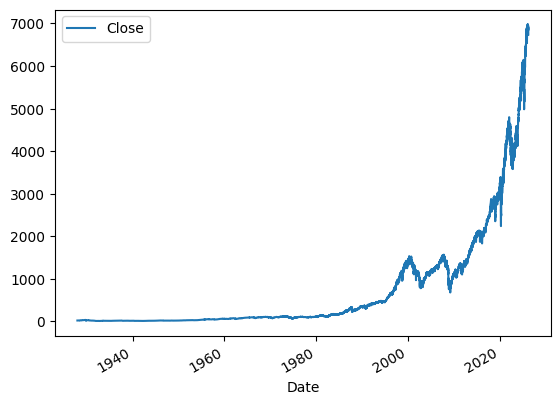

In [6]:
sp500.plot.line(y="Close", use_index=True)

In [ ]:
sp500 = sp500.drop(columns=["Dividends", "Stock Splits"])

We need to setup a target for machine learning so that it can predict tommorows price

In [8]:
# we will create a new column i.e tommorow and will add closing price of the next day into it

In [9]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [10]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-03-02 00:00:00-05:00,6824.359863,6901.009766,6796.850098,6881.620117,6079080000,6816.629883
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,6830.709961


In [11]:
sp500["Target"] = (sp500["Tomorrow"]>sp500["Close"]).astype(int)

In [12]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-03-02 00:00:00-05:00,6824.359863,6901.009766,6796.850098,6881.620117,6079080000,6816.629883,0
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000,1
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,6830.709961,0


In [13]:
sp500 = sp500.loc["1990-01-01":].copy()

In [14]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-03-02 00:00:00-05:00,6824.359863,6901.009766,6796.850098,6881.620117,6079080000,6816.629883,0
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000,1
2026-03-04 00:00:00-05:00,6831.689941,6885.939941,6811.640137,6869.500000,5252170000,6830.709961,0


In [15]:
# Moving averages
sp500["MA10"] = sp500["Close"].rolling(10).mean()
sp500["MA50"] = sp500["Close"].rolling(50).mean()
sp500["MA200"] = sp500["Close"].rolling(200).mean()

# Price momentum
sp500["Momentum"] = sp500["Close"] - sp500["Close"].shift(5)

# Volatility
sp500["Volatility"] = sp500["Close"].pct_change().rolling(5).std()

# Daily returns
sp500["Daily_Return"] = sp500["Close"].pct_change()

sp500 = sp500.dropna()

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1) #n_estimatprs is the no. of decision tree that should be used,min_samples_split=100 means that a node in any of the decision trees within the random forest will only be split if it contains at least 100 data points.
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = predictors = [
    "Close",
    "Volume",
    "MA50",
    "MA200",
    "Momentum"
]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=50, n_estimators=200, random_state=1)

In [17]:
from sklearn.metrics import precision_score
preds = model.predict(test[predictors])

In [18]:
preds = pd.Series(preds, index=test.index)

In [19]:
precision_score(test["Target"], preds)

0.6031746031746031

In [20]:
combined = pd.concat([test["Target"],preds],axis =1)

<Axes: xlabel='Date'>

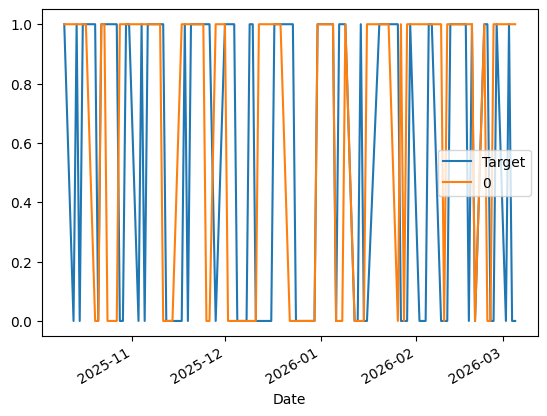

In [21]:
combined.plot()

Backtesting

In [22]:
def predict(train, test, predictors, model):
  model.fit(train[predictors],train["Target"])
  preds = model.predict(test[predictors])
  preds = pd.Series(preds, index=test.index, name="Predictions")
  combined = pd.concat([test["Target"], preds], axis=1)
  return combined

In [23]:
def backtest(data, model, predictors, start = 2500, step = 250):    #start is 2500 means we are starting with 10 years of data and at each step one year will be incremented (i.e steps)
  all_predictions = []

  for i in range(start, data.shape[0], step):
    train = data.iloc[0:i].copy()
    test = data.iloc[i:(i+step)].copy()
    predictions = predict(train, test, predictors, model)
    all_predictions.append(predictions)

  return pd.concat(all_predictions)


In [24]:
predictions = backtest(sp500, model, predictors)

In [25]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,3577
1,2834


In [26]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5317572335920959

In [27]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.537982
0,0.462018


Adding additional predictors to the model

In [28]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
  rolling_averages = sp500.rolling(horizon).mean()

  ratio_column = 'adj_close_ratio_' + str(horizon)
  sp500[ratio_column] = sp500['Close'] / rolling_averages['Close']

  trend_column = 'trend_' + str(horizon)
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()['Target']

  new_predictors += [ratio_column, trend_column]

/tmp/ipykernel_240/3671230605.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp500[ratio_column] = sp500['Close'] / rolling_averages['Close']
/tmp/ipykernel_240/3671230605.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()['Target']
/tmp/ipykernel_240/3671230605.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [29]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,MA10,MA50,MA200,...,adj_close_ratio_2,trend_2,adj_close_ratio_5,trend_5,adj_close_ratio_60,trend_60,adj_close_ratio_250,trend_250,adj_close_ratio_1000,trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
1990-10-15 00:00:00-04:00,300.029999,304.790009,296.410004,303.230011,164980000,298.920013,0,306.849002,318.629400,338.926850,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-10-16 00:00:00-04:00,303.230011,304.339996,298.119995,298.920013,149570000,298.760010,0,305.220004,317.919200,338.623000,...,0.992842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-10-17 00:00:00-04:00,298.920013,301.500000,297.790009,298.760010,161260000,305.739990,1,303.956006,317.197801,338.323000,...,0.999732,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-10-18 00:00:00-04:00,298.750000,305.739990,298.750000,305.739990,204110000,312.480011,1,303.261005,316.545601,338.073350,...,1.011547,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-10-19 00:00:00-04:00,305.739990,312.480011,305.739990,312.480011,221480000,314.760010,1,303.359006,315.996401,337.874750,...,1.010902,2.0,1.028483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27 00:00:00-05:00,6856.540039,6882.959961,6831.740234,6878.879883,6665660000,6881.620117,1,6879.378955,6899.869180,6559.926282,...,0.997826,0.0,0.998047,2.0,0.998099,32.0,1.081955,143.0,1.348129,536.0
2026-03-02 00:00:00-05:00,6824.359863,6901.009766,6796.850098,6881.620117,6079080000,6816.629883,0,6883.923975,6901.496387,6564.901633,...,1.000199,1.0,0.997176,3.0,0.998371,32.0,1.081684,144.0,1.347991,537.0
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000,1,6881.264941,6903.400381,6569.521882,...,0.995256,1.0,0.989865,2.0,0.989021,31.0,1.070769,144.0,1.334577,537.0


In [30]:
sp500.dropna()

,Open,High,Low,Close,Volume,Tomorrow,Target,MA10,MA50,MA200,...,adj_close_ratio_2,trend_2,adj_close_ratio_5,trend_5,adj_close_ratio_60,trend_60,adj_close_ratio_250,trend_250,adj_close_ratio_1000,trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
1994-09-28 00:00:00-04:00,462.100006,465.549988,462.100006,464.839996,330020000,462.239990,0,465.031998,463.775200,460.936500,...,1.003010,2.0,1.006736,3.0,1.007084,33.0,1.007265,135.0,1.111979,514.0
1994-09-29 00:00:00-04:00,464.839996,464.839996,461.510010,462.239990,302280000,462.709991,1,463.774997,463.987999,460.932400,...,0.997195,1.0,1.000684,3.0,1.000869,33.0,1.001623,134.0,1.105327,514.0
1994-09-30 00:00:00-04:00,462.269989,465.299988,461.910004,462.709991,291900000,461.739990,0,462.926996,464.189999,460.936750,...,1.000508,1.0,1.000385,4.0,1.001369,33.0,1.002629,135.0,1.106017,515.0
1994-10-03 00:00:00-04:00,462.690002,463.309998,460.329987,461.739990,269130000,454.589996,0,462.015994,464.362599,460.928750,...,0.998951,1.0,0.997891,3.0,0.998830,32.0,1.000518,135.0,1.103287,514.0
1994-10-04 00:00:00-04:00,461.769989,462.459991,454.029999,454.589996,325620000,453.519989,0,461.138995,464.369399,460.869800,...,0.992197,0.0,0.985617,2.0,0.983132,32.0,0.985064,135.0,1.085834,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27 00:00:00-05:00,6856.540039,6882.959961,6831.740234,6878.879883,6665660000,6881.620117,1,6879.378955,6899.869180,6559.926282,...,0.997826,0.0,0.998047,2.0,0.998099,32.0,1.081955,143.0,1.348129,536.0
2026-03-02 00:00:00-05:00,6824.359863,6901.009766,6796.850098,6881.620117,6079080000,6816.629883,0,6883.923975,6901.496387,6564.901633,...,1.000199,1.0,0.997176,3.0,0.998371,32.0,1.081684,144.0,1.347991,537.0
2026-03-03 00:00:00-05:00,6800.259766,6840.049805,6710.419922,6816.629883,6442080000,6869.500000,1,6881.264941,6903.400381,6569.521882,...,0.995256,1.0,0.989865,2.0,0.989021,31.0,1.070769,144.0,1.334577,537.0


In [31]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [32]:
def predict(train, test, predictors, model):
  model.fit(train[predictors],train["Target"])
  preds = model.predict_proba(test[predictors]) [:,1]
  preds [preds >= 0.6] = 1
  preds [preds < 0.6] = 0
  preds = pd.Series(preds, index=test.index, name="Predictions")
  combined = pd.concat([test["Target"], preds], axis=1)
  return combined

In [34]:
predictions = backtest(sp500, model, new_predictors)

In [35]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,5246
1.0,1165


In [36]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5356223175965665

In [37]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.537982
0,0.462018


In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
preds = model.predict(test[new_predictors])

print("Accuracy:", accuracy_score(test["Target"], preds))

print("\nConfusion Matrix:")
print(confusion_matrix(test["Target"], preds))

print("\nClassification Report:")
print(classification_report(test["Target"], preds))

Accuracy: 0.57

Confusion Matrix:
[[32 12]
 [31 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.73      0.60        44
           1       0.68      0.45      0.54        56

    accuracy                           0.57       100
   macro avg       0.59      0.59      0.57       100
weighted avg       0.60      0.57      0.56       100



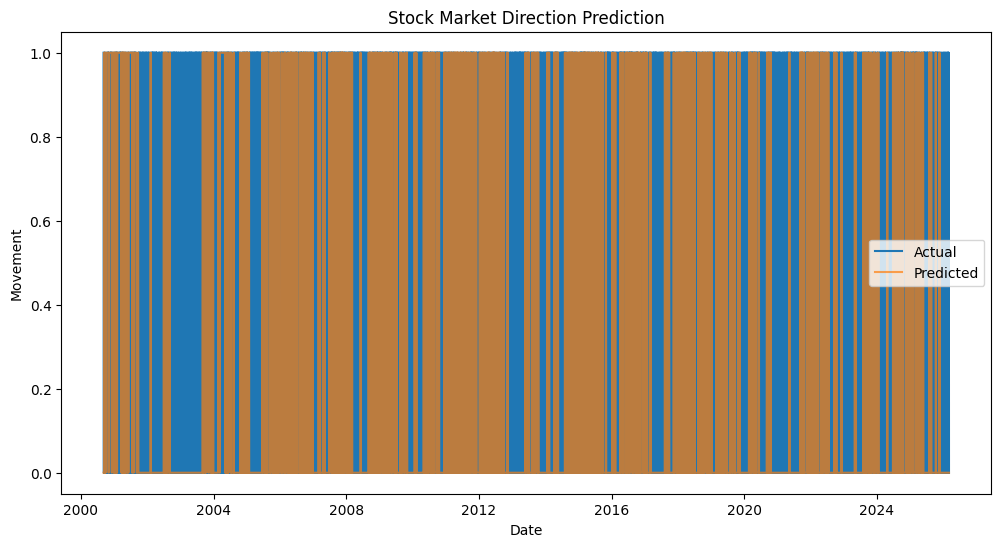

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(predictions.index, predictions["Target"], label="Actual")
plt.plot(predictions.index, predictions["Predictions"], label="Predicted", alpha=0.7)

plt.title("Stock Market Direction Prediction")
plt.xlabel("Date")
plt.ylabel("Movement")
plt.legend()
plt.show()

Importance of Features

In [43]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=new_predictors)
importance.sort_values(ascending=False)

,0
adj_close_ratio_2,0.151727
adj_close_ratio_5,0.151105
adj_close_ratio_60,0.147495
adj_close_ratio_250,0.143228
adj_close_ratio_1000,0.133525
trend_1000,0.084144
trend_250,0.082118
trend_60,0.060849
trend_5,0.031151
trend_2,0.014658


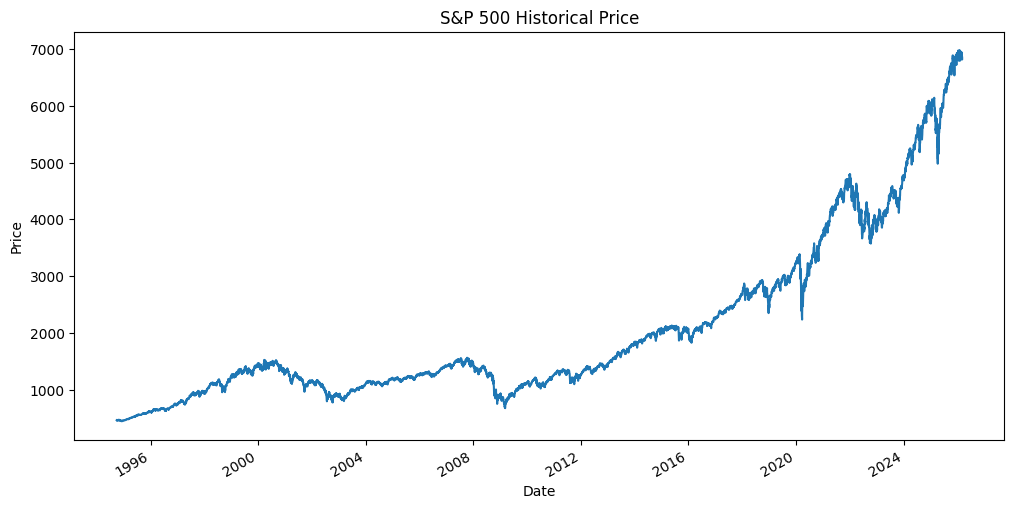

In [44]:
plt.figure(figsize=(12,6))
sp500["Close"].plot()

plt.title("S&P 500 Historical Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()